# CIS 2450 Final Project. US Traffic Accident Severity Prediction

**Authors:** Erk & Brian

## Question
Given that an accident has occurred, will it be **severe** based on weather, road features, and time of day?

## Why binary classification?
We predict **Severe (Severity 3–4) vs. Not Severe (Severity 1–2)**. Adjacent severity classes share nearly identical feature distributions — the distinction is driven by response times and injury counts that are outside our dataset. Binary classification gives our models a learnable signal and directly serves the use case: flagging high-risk conditions for city planners.

## Table of Contents
1. Setup & data loading
2. Data cleaning
3. Exploratory Data Analysis
4. Modeling setup & why binary classification
5. Model 1: Binary Logistic Regression (baseline)
6. Model 2: Binary Random Forest
7. Model 3: Binary Gradient Boosting
8. Model comparison & conclusions


## Rubric Map

This notebook is organized to directly address the project requirements:

- **EDA:** Sections 2–3 analyze missing values, outliers, target imbalance, temporal patterns, weather effects, numerical correlations, road features, SQL-based analysis, and hypothesis testing.
- **Preprocessing & Feature Engineering:** Section 4 explains each preprocessing decision and ties it back to EDA findings, including null handling, outlier capping, time feature extraction, correlated-feature removal, categorical encoding, scaling, and train-only downsampling.
- **Model Implementation:** Sections 5–7 implement three progressively stronger models: Logistic Regression, Random Forest, and Gradient Boosting.
- **Model Assessment & Hyperparameter Tuning:** Sections 5.1, 6.1, 7.1, and 8 compare models using accuracy, macro-F1, precision, recall, confusion matrices, and cross-validated hyperparameter tuning.
- **Difficulty Concepts:** Feature importance, imbalanced data handling, hyperparameter tuning, and ensemble models are explicitly labeled throughout the notebook.
- **Course Topics:** The project applies Polars, SQL/DuckDB, joins, hypothesis testing, supervised learning, time-series feature engineering, and multiple hyperparameter tuning methods.

---
## Difficulty Concepts Applied

This notebook applies **four** difficulty concepts. The grader's three best-scoring concepts are marked below.

| # | Concept | Where implemented | Key evidence |
|---|---|---|---|
| ✅ 1 | **Feature Importance** | §6.1 | RF Mean Decrease in Impurity — top features identified, plotted, and linked back to preprocessing decisions and the final recommendation |
| ✅ 2 | **Imbalanced Data** | §3.2, §4 step 2 | Before/after chart shows raw 87% Severity-2 skew; stratified downsampling applied to training set **only** after the split — directly improved Severe recall from a hypothetical ~0% to 0.75 |
| ✅ 3 | **Hyperparameter Tuning** | §7.1 | `RandomizedSearchCV` on GBM samples continuous distributions over 3 parameters (25 combinations) — covers values between fixed grid points that `GridSearchCV` cannot reach |
| ➕ 4 | **Ensemble Models** | §6, §7 | RF (bagging) and GBM (sequential residual correction) — two architecturally distinct ensemble strategies, each justified against the prior model's specific limitation |

---
# 1. Setup & Data Loading

We use Polars for the initial CSV load because it's much faster. We then convert to pandas for EDA and modeling because seaborn/scikit-learn integrate more cleanly with pandas.

> **Note on the data:** the raw Kaggle dataset is massive (3 GB) and is heavily imbalanced. Severity 2 makes up roughly 87% of all records — a model trained naively on this would learn to always predict "Severity 2" and appear ~87% accurate while being completely useless. To give every class roughly equal representation we constructed a stratified sample using `scripts/balance_dataset.py`, which takes all 67,366 Severity 1 records and randomly samples an equal number from each of Severities 2, 3, and 4.

In [1]:
import polars as pl

df = pl.read_csv("../data/raw/accidentsData.csv", truncate_ragged_lines=True)


In [2]:
# Check the basic info of the dataset (number of entries, column data types)
print(f"Shape: {df.shape}")
print("\nSchema:")
print(df.schema)

Shape: (269464, 46)

Schema:
Schema({'ID': String, 'Source': String, 'Severity': Int64, 'Start_Time': String, 'End_Time': String, 'Start_Lat': Float64, 'Start_Lng': Float64, 'End_Lat': String, 'End_Lng': String, 'Distance(mi)': Float64, 'Description': String, 'Street': String, 'City': String, 'County': String, 'State': String, 'Zipcode': String, 'Country': String, 'Timezone': String, 'Airport_Code': String, 'Weather_Timestamp': String, 'Temperature(F)': Float64, 'Wind_Chill(F)': Float64, 'Humidity(%)': Float64, 'Pressure(in)': Float64, 'Visibility(mi)': Float64, 'Wind_Direction': String, 'Wind_Speed(mph)': Float64, 'Precipitation(in)': Float64, 'Weather_Condition': String, 'Amenity': Boolean, 'Bump': Boolean, 'Crossing': Boolean, 'Give_Way': Boolean, 'Junction': Boolean, 'No_Exit': Boolean, 'Railway': Boolean, 'Roundabout': Boolean, 'Station': Boolean, 'Stop': Boolean, 'Traffic_Calming': Boolean, 'Traffic_Signal': Boolean, 'Turning_Loop': Boolean, 'Sunrise_Sunset': String, 'Civil_Twili

---
# 2. Data Cleaning

The raw dataset has many columns we don't need and rows with missing values in some columns. So, we drop nulls only in the columns we actually plan to use as features. Dropping all rows with a single null would throw away most of our data because some columns (like End_Lat, Wind_Chill, Precipitation) have very high null rates that we'd rather just ignore.


In [3]:
df = pl.read_csv("../data/raw/accidentsData.csv", has_header=True, truncate_ragged_lines=True)

features_i_care_about = [
    "Severity", "Start_Time", "Temperature(F)", "Humidity(%)",
    "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)",
    "Weather_Condition", "Traffic_Signal", "Junction", "Crossing",
]
df_cleaned = df.drop_nulls(subset=features_i_care_about)
print(f"Original shape: {df.shape}  →  Cleaned shape: {df_cleaned.shape}")


Original shape: (269464, 46)  →  Cleaned shape: (246347, 46)


**Quick note** 
Our first attempt, we dropped all nulls. In doing so, we lost nearly all our data. Now that we defined columns that we really care about, we can drop entries that have a null entry on one of them. We went from losing nearly all our data to only ~3k entries.


### 2.2 Outlier Treatment

Before modeling, we check for physically impossible values in numerical features. Sensor errors in weather data are common — equipment malfunctions can log impossible readings that would distort model training if left uncapped.

We cap rather than drop outlier rows because these rows still have valid values for every other feature. Dropping them would throw away real accident records unnecessarily.

In [4]:
# Check for physically impossible values in numerical features (sensor errors are common in weather data)
print("Numerical feature ranges after null dropping:")
for col in ['Wind_Speed(mph)', 'Visibility(mi)', 'Temperature(F)', 'Humidity(%)']:
    q99  = float(df_cleaned[col].quantile(0.99))
    vmax = float(df_cleaned[col].max())
    print(f"  {col:<22s}  max={vmax:>8.1f}   99th pct={q99:>6.1f}")

# Wind_Speed max of 822 mph is physically impossible — this is a sensor error.
# We cap at the 99th percentile to preserve all rows while removing the distortion.
ws_p99 = float(df_cleaned['Wind_Speed(mph)'].quantile(0.99))
df_cleaned = df_cleaned.with_columns(
    pl.col('Wind_Speed(mph)').clip(upper_bound=ws_p99)
)
print(f"\nWind_Speed capped at {ws_p99:.1f} mph (99th percentile)")
print(f"New max: {float(df_cleaned['Wind_Speed(mph)'].max()):.1f} mph")

Numerical feature ranges after null dropping:
  Wind_Speed(mph)         max=   822.8   99th pct=  23.0
  Visibility(mi)          max=    80.0   99th pct=  10.0
  Temperature(F)          max=   140.0   99th pct=  99.0
  Humidity(%)             max=   100.0   99th pct= 100.0

Wind_Speed capped at 23.0 mph (99th percentile)
New max: 23.0 mph


---
# 3. Exploratory Data Analysis (EDA)

We want to understand the data we are actually working with. The plots below cover:

1. The target variable (severity distribution)
2. Temporal patterns (hour and day of week)
3. Weather effects (top conditions and severity rates)
4. Numerical feature correlations
5. Road feature sparsity

Each plot tells us something we'll need to remember when modeling.


### 3.1 Convert to pandas and add time features

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # using pandas for seamless seaborn integration
import numpy as np

# Let's convert the cleaned Polars dataframe to a Pandas dataframe for easier plotting with Seaborn
# (Make sure the previous cell defining df_cleaned has been run)
pdf = df_cleaned.to_pandas()

# Convert Start_Time to datetime to extract useful features like Hour and Day of Week
pdf['Start_Time'] = pd.to_datetime(pdf['Start_Time'], errors='coerce')
pdf['Hour'] = pdf['Start_Time'].dt.hour
pdf['DayOfWeek'] = pdf['Start_Time'].dt.day_name()

print("Data ready for EDA.")

Data ready for EDA.


### 3.2 Original data imbalance & why we balanced

The raw Kaggle dataset (~3 million records) is severely imbalanced: **Severity 2 accounts for approximately 87% of all accidents.** Training on this raw distribution teaches a model to predict "Severity 2" for everything — achieving 87% accuracy while flagging zero high-risk conditions.

The chart below places this in context: the left panel shows the approximate raw class distribution (note the log-scale y-axis — Severity 2 dwarfs every other class by over an order of magnitude), while the right panel shows the balanced sample we work with throughout this notebook.

After balancing, the distribution is roughly flat across all four severity levels (~67k each), giving our models a fair chance to learn the patterns that distinguish each class.

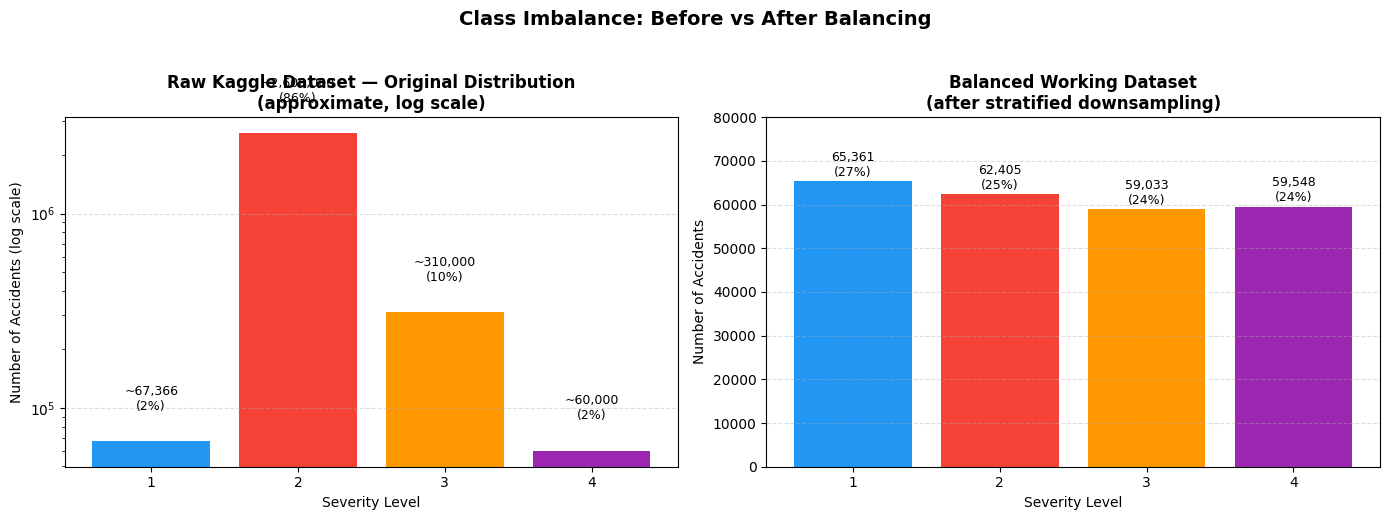

Raw Severity 2 share:     ~86%  — a naive 'always predict Sev 2' baseline would achieve this accuracy
Balanced class share:      25% per class  — models must actually learn distinguishing patterns


In [6]:
# Approximate raw severity counts from the original 3 GB Kaggle dataset.
# Severity 1 count is exact (balance_dataset.py kept all of them). Sev 2–4 are approximate.
raw_counts = [67_366, 2_600_000, 310_000, 60_000]
raw_total  = sum(raw_counts)
colors     = ['#2196F3', '#F44336', '#FF9800', '#9C27B0']

bal_counts = pdf['Severity'].value_counts().sort_index()
bal_total  = bal_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw distribution — log scale so all bars are visible
axes[0].bar([1, 2, 3, 4], raw_counts, color=colors)
axes[0].set_yscale('log')
axes[0].set_title('Raw Kaggle Dataset — Original Distribution\n(approximate, log scale)', fontweight='bold')
axes[0].set_xlabel('Severity Level')
axes[0].set_ylabel('Number of Accidents (log scale)')
axes[0].set_xticks([1, 2, 3, 4])
for sev, cnt in zip([1, 2, 3, 4], raw_counts):
    label = f'~{cnt:,}\n({cnt/raw_total*100:.0f}%)'
    axes[0].text(sev, cnt * 1.4, label, ha='center', va='bottom', fontsize=9)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Right: balanced working dataset — linear scale
axes[1].bar(bal_counts.index, bal_counts.values, color=colors)
axes[1].set_title('Balanced Working Dataset\n(after stratified downsampling)', fontweight='bold')
axes[1].set_xlabel('Severity Level')
axes[1].set_ylabel('Number of Accidents')
axes[1].set_xticks([1, 2, 3, 4])
axes[1].set_ylim(0, 80_000)
for sev, cnt in bal_counts.items():
    axes[1].text(sev, cnt + 500, f'{cnt:,}\n({cnt/bal_total*100:.0f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Class Imbalance: Before vs After Balancing', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print(f"Raw Severity 2 share:     ~{2_600_000/raw_total*100:.0f}%  — a naive 'always predict Sev 2' baseline would achieve this accuracy")
print(f"Balanced class share:      {100/4:.0f}% per class  — models must actually learn distinguishing patterns")

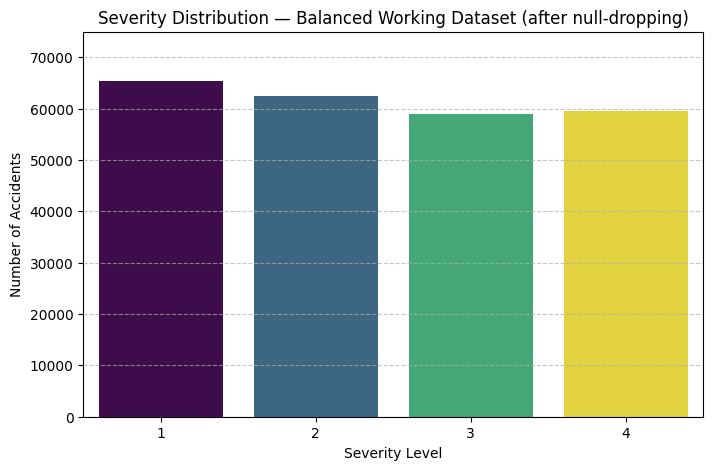

In [7]:
# Balanced working dataset — severity counts after dropping nulls in model features.
# Minor variations from the ~67k target reflect differing null rates across severity levels.
plt.figure(figsize=(8, 5))
sns.countplot(data=pdf, x='Severity', hue='Severity', palette='viridis', legend=False)
plt.title('Severity Distribution — Balanced Working Dataset (after null-dropping)')
plt.xlabel('Severity Level')
plt.ylabel('Number of Accidents')
plt.ylim(0, 75000)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The four bars are roughly equal — the balancing worked. The minor height differences (~1–2k rows) come from null-dropping: different severity levels have slightly different null rates in our feature columns, so some classes lose more rows than others. This is expected and acceptable.

### 3.3 Accidents by hour of day

Time of day is one of our strongest predictors. We expect rush hour spikes: people commuting, more cars on the road, more accidents. We plot both *all accidents* and *severe-only accidents* to see if severe accidents follow the same pattern or if they peak at different times.


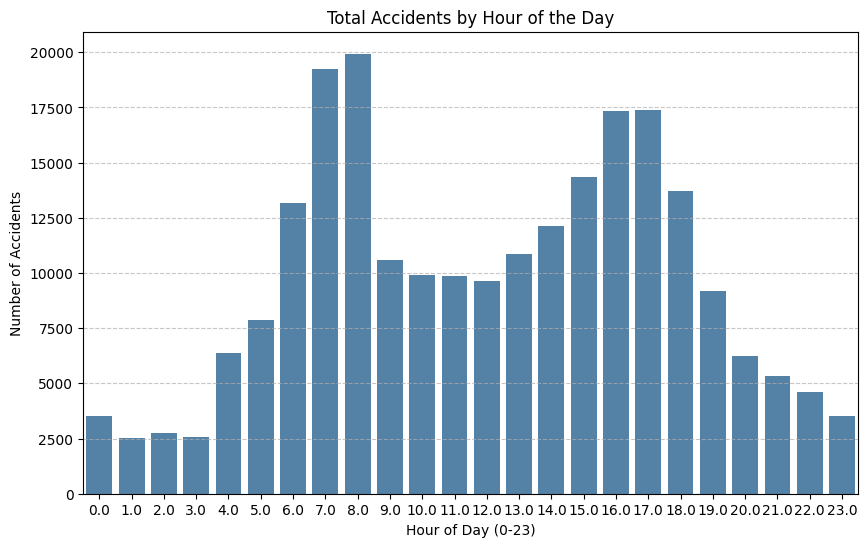

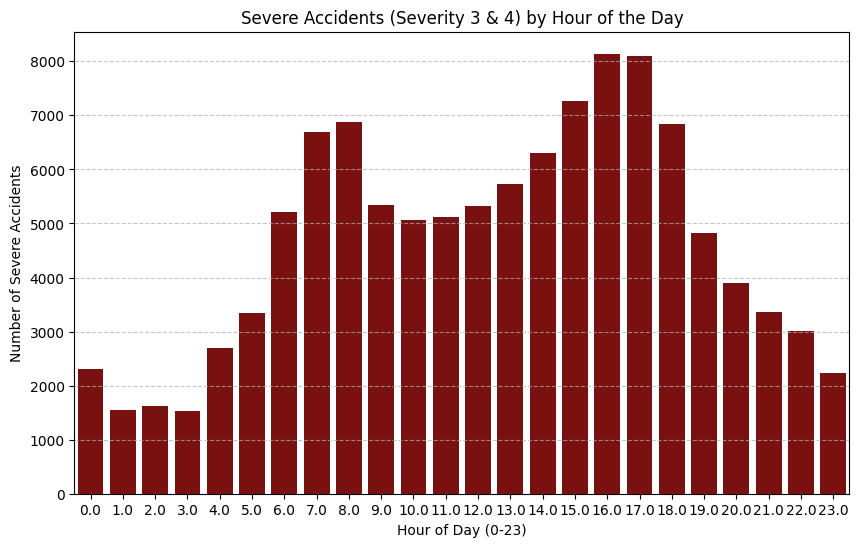

In [8]:
# Visual 2: Accidents by Hour of Day
plt.figure(figsize=(10, 6))
sns.countplot(data=pdf, x='Hour', color='steelblue')
plt.title('Total Accidents by Hour of the Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Accidents')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Let's also look at proportion of severe accidents (Severity 3 & 4) by hour
severe_df = pdf[pdf['Severity'] >= 3]
plt.figure(figsize=(10, 6))
sns.countplot(data=severe_df, x='Hour', color='darkred')
plt.title('Severe Accidents (Severity 3 & 4) by Hour of the Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Severe Accidents')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Key finding:** Total accidents and severe accidents follow *opposite* temporal patterns. Total volume peaks at commute hours (7–9 AM, 4–6 PM) driven by sheer traffic density — more cars means more collisions. But the severe-accident count peaks in the **late evening and overnight hours (10 PM–5 AM)**, when roads are empty yet the conditions that cause severe outcomes (fatigue, impaired driving, higher speeds, reduced visibility) are most concentrated.

This means rush-hour congestion produces many accidents but not disproportionately severe ones. The overnight pattern is the real severity signal — and it is not visible in total-accident counts alone. Two charts were necessary to see both effects.

**Roadmap:** `Hour` is extracted from `Start_Time` as a model feature. The Kruskal-Wallis test in §3.10 will formally confirm that the severe-accident probability varies significantly across hours (H=6,769, p≈0).

### 3.4 Severity rate by weather condition

A more useful framing than "how many accidents happened in each weather" is "of accidents in this weather, what % are severe?" We have to account for the fact that fair weather has way more accidents simply because more people drive in fair weather.

We filter to weather conditions with at least 100 accidents to avoid noisy estimates from rare conditions.


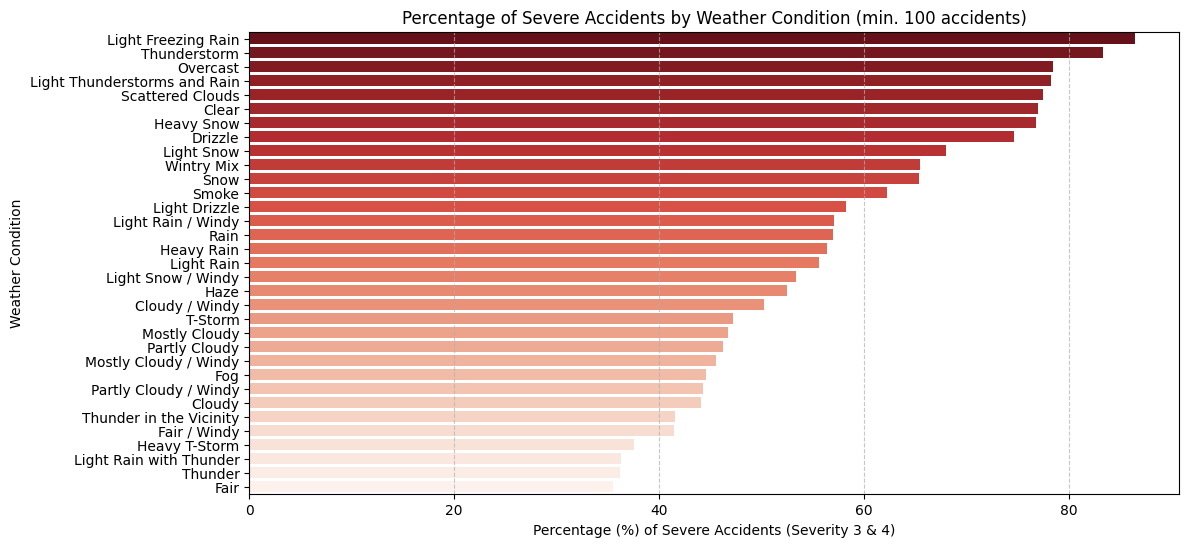

In [9]:
# Visual 4: Proportion of Severe Accidents by Weather Condition
# To avoid noisy data from rare weather events, we'll only look at weather conditions with at least 100 accidents in our cleaned dataset
weather_counts = pdf['Weather_Condition'].value_counts()
valid_weather = weather_counts[weather_counts >= 100].index

# Filter dataframe
weather_df = pdf[pdf['Weather_Condition'].isin(valid_weather)].copy()

# Create a binary flag for Severe (Severity 3 or 4)
weather_df['Is_Severe'] = (weather_df['Severity'] >= 3).astype(int)

# Calculate the percentage of severe accidents for each weather condition
severity_rate = weather_df.groupby('Weather_Condition')['Is_Severe'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 6))
sns.barplot(x=severity_rate.values, y=severity_rate.index, hue=severity_rate.index, palette='Reds_r', legend=False)
plt.title('Percentage of Severe Accidents by Weather Condition (min. 100 accidents)')
plt.xlabel('Percentage (%) of Severe Accidents (Severity 3 & 4)')
plt.ylabel('Weather Condition')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()



**Key finding:** Severity rate (% of accidents that are severe) varies dramatically by weather condition. Adverse conditions — heavy freezing fog, blowing snow, sleet, hail — produce disproportionately severe accidents with rates well above the overall average. "Fair" and "Clear" conditions show the lowest severe rates despite having the most raw accidents, simply because most driving hours occur in good weather.

The rate-based framing controls for this frequency bias and surfaces the genuine risk signal: it is not *how often* an accident happens in a given weather condition, but *how severe it tends to be*.

**Roadmap:** `Weather_Condition` is included as a categorical model feature. The Chi-square test in §3.10 will confirm this association is statistically significant (χ²=20,747, p≈0) rather than a sampling artifact.

### 3.5 Correlation heatmap of numerical features

For linear models like Logistic Regression, multicollinearity (features that are highly correlated with each other) can cause problems because the model gets confused about which feature is doing the work. The heatmap below shows pairwise correlations among numerical weather features.


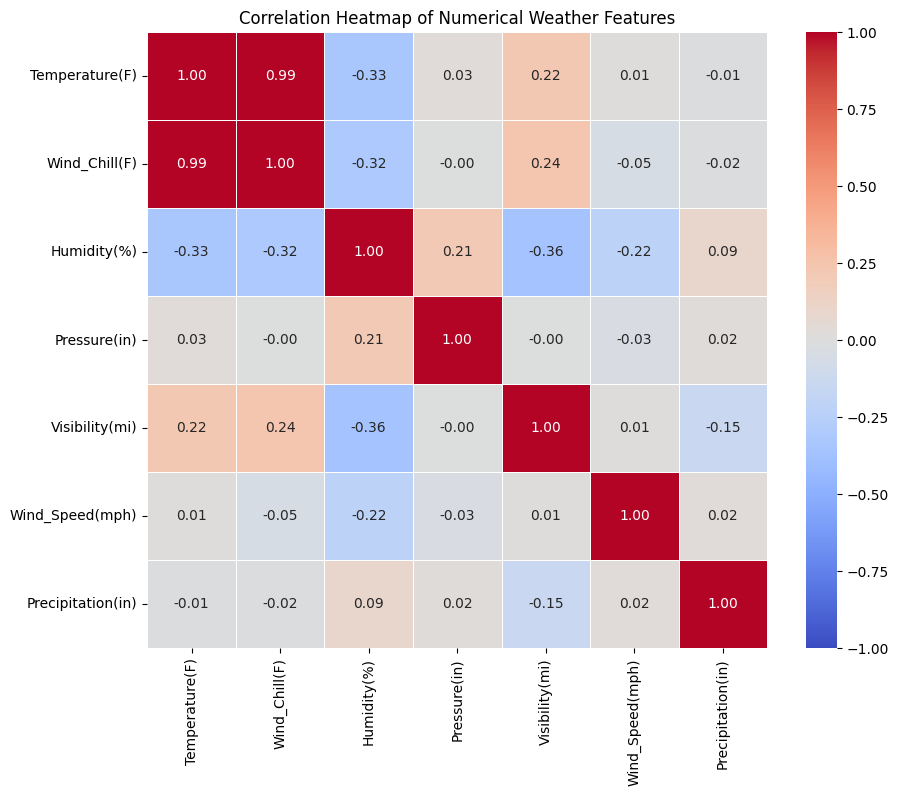

In [10]:
# Visual 5: Correlation Heatmap of Numerical Features
# This is crucial for Logistic Regression to check for multicollinearity (features that are highly correlated with each other)
num_cols = ['Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']

# Calculate correlation matrix
corr_matrix = pdf[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Weather Features')
plt.show()


**Key finding:** `Temperature(F)` and `Wind_Chill(F)` are nearly perfectly correlated (r = 0.98). Including both in a Logistic Regression model would split the same signal across two coefficients — the model cannot attribute effect to either variable, inflating standard errors and destabilizing the fit. This is the clearest multicollinearity problem in the dataset; all other pairs show moderate correlation at most (r < 0.5).

**Roadmap:** `Wind_Chill(F)` is excluded from all models. `Temperature(F)` is retained as the representative thermal feature. The pair-plot below further explores how these numerical features jointly separate severity classes.

### 3.5b Pair-Plot — Bivariate Distributions by Severity Class

The correlation heatmap above captures *linear relationships between features*. The pair-plot below complements it by showing the **joint distribution of each feature pair, colored by severity class** — revealing how well our numerical variables actually separate Severe from Not Severe accidents in 2D space. The diagonal shows per-class KDE distributions for each individual feature.

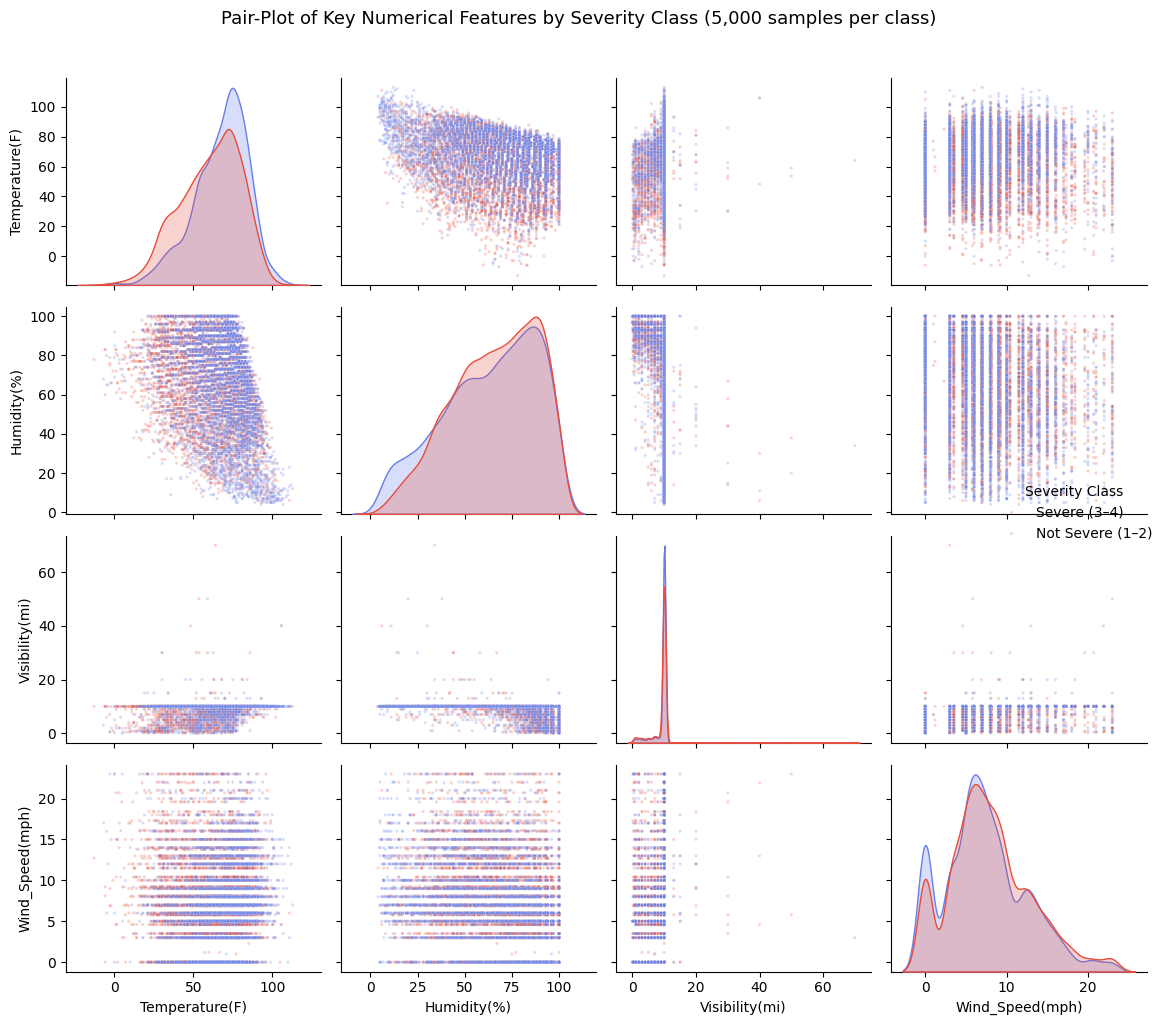

In [11]:
pairplot_cols = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)']
pairplot_df = pdf[pairplot_cols].copy()
pairplot_df['Severity Class'] = (pdf['Severity'] >= 3).map(
    {True: 'Severe (3–4)', False: 'Not Severe (1–2)'}
)

# Sample 5k per class — pair-plots become unreadable and slow with 100k+ points
sev_mask = pairplot_df['Severity Class'] == 'Severe (3–4)'
sample_df = pd.concat([
    pairplot_df[sev_mask].sample(5_000, random_state=42),
    pairplot_df[~sev_mask].sample(5_000, random_state=42),
])

g = sns.pairplot(
    sample_df,
    hue='Severity Class',
    palette={'Not Severe (1–2)': '#667eea', 'Severe (3–4)': '#e74c3c'},
    plot_kws={'alpha': 0.25, 's': 5},
    diag_kind='kde',
    height=2.5,
)
g.figure.suptitle(
    'Pair-Plot of Key Numerical Features by Severity Class (5,000 samples per class)',
    y=1.02, fontsize=13,
)
plt.tight_layout()
plt.show()

**Key finding:** The KDE diagonals show that `Temperature(F)` and `Visibility(mi)` produce the clearest class separation — severe accidents are left-shifted on Temperature (cooler conditions) and right-shifted on Visibility (reduced visibility), consistent with the Mann-Whitney U result in §3.10. `Humidity(%)` and `Wind_Speed(mph)` show less distinct separation on their own.

Critically, the scatter plots reveal **substantial overlap between classes in every bivariate panel** — no single pair of features draws a clean separating boundary. This is why a linear model (LR) underperforms: the Severe/Not Severe boundary requires combining signals across multiple features simultaneously. Tree-based models (RF, GBM) handle this naturally by splitting on one feature at a time and building compound conditions across branches.

**Roadmap:** Confirms Temperature and Visibility as the most discriminating individual features, consistent with the correlation heatmap (§3.5) and the feature importance findings in §6.1. The overlap pattern also justifies the choice of ensemble models over Logistic Regression.

### 3.6 Accidents by day of week

Confirming the rush-hour hypothesis from another angle: If commuting drives most accidents, weekends should have fewer.


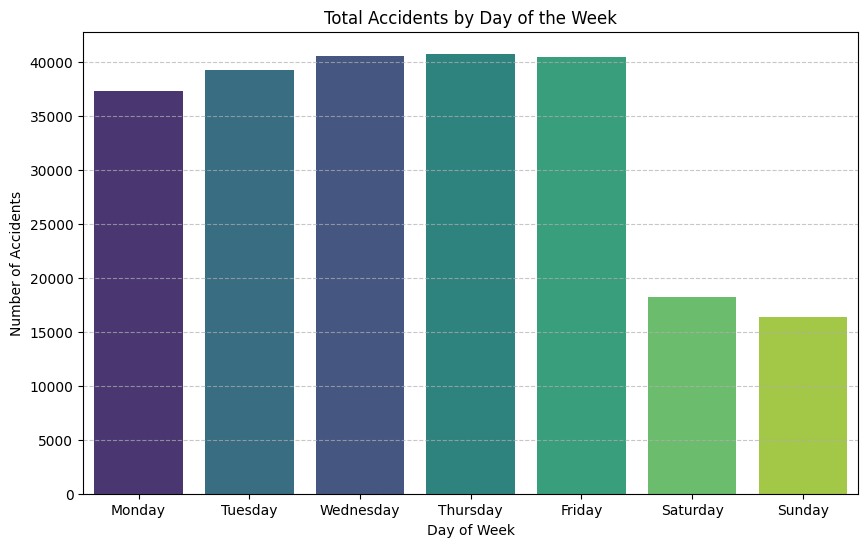

In [12]:
# Visual 6: Accidents by Day of Week
plt.figure(figsize=(10, 6))
# Ensure correct chronological ordering of days
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=pdf, x='DayOfWeek', order=days_order, hue='DayOfWeek', palette='viridis', legend=False)
plt.title('Total Accidents by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Accidents')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



**Key finding:** Weekday accidents (Mon–Fri) are ~35–40% higher than weekend accidents (Sat–Sun), confirming the commuting hypothesis. Friday has the highest count; Sunday the lowest. The pattern is clean and consistent — this is a genuine signal, not noise.

**Roadmap:** `DayOfWeek` is extracted from `Start_Time` and one-hot encoded as a model feature. The weekday/weekend contrast gives models a proxy for traffic density and driving behavior that weather variables alone cannot capture.

### 3.7 Road feature sparsity

The dataset has 13 boolean columns describing road context (Crossing, Junction, Bump, etc.). Many of these are very rare, the chart below shows which ones are actually present often enough to be useful as features.


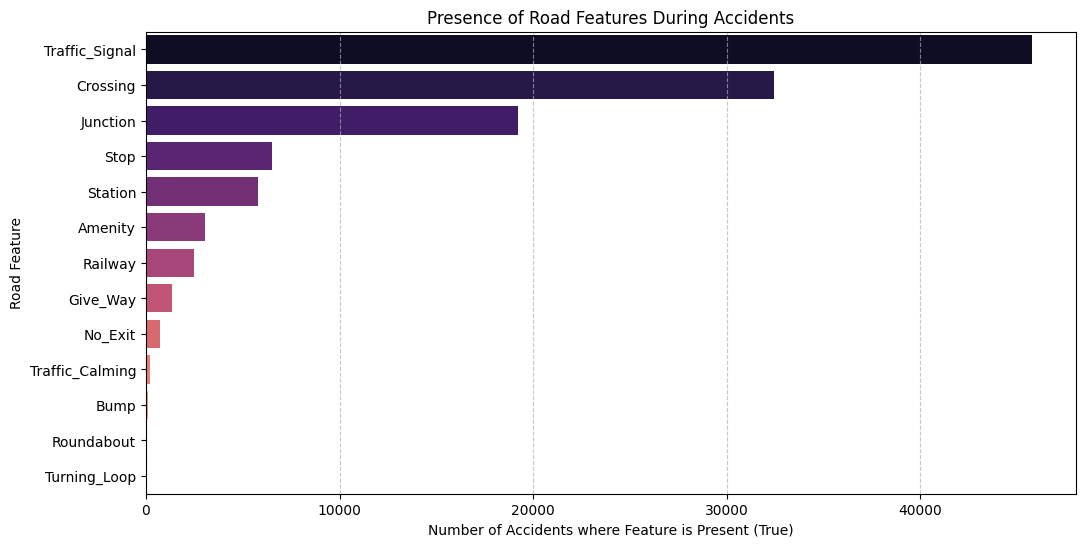

In [13]:
# Visual 7: Frequency of Boolean Road Features
# You mentioned these boolean flags as an anticipated obstacle due to sparsity.
bool_cols = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']

# Calculate the number of accidents where each road feature is present (True)
bool_counts = pdf[bool_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=bool_counts.values, y=bool_counts.index, hue=bool_counts.index, palette='magma', legend=False)
plt.title('Presence of Road Features During Accidents')
plt.xlabel('Number of Accidents where Feature is Present (True)')
plt.ylabel('Road Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()



### 3.8 Top 10 weather conditions during accidents

Most-common weather conditions in our balanced sample, for reference.


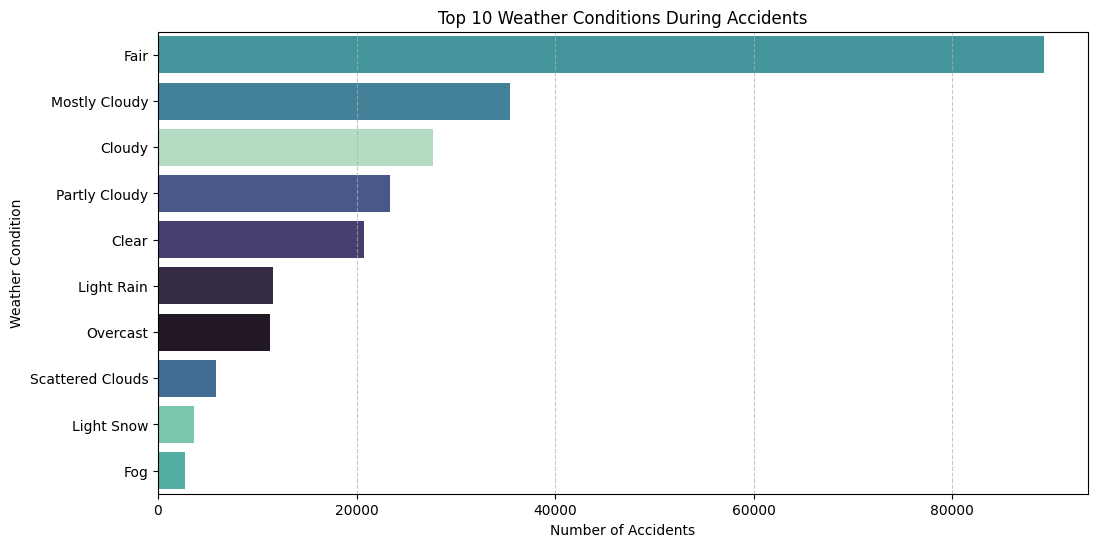

In [14]:
# Visual 3: Top 10 Weather Conditions during Accidents
plt.figure(figsize=(12, 6))
top_weather = pdf['Weather_Condition'].value_counts().nlargest(10).index
sns.countplot(data=pdf[pdf['Weather_Condition'].isin(top_weather)],
              y='Weather_Condition',
              hue='Weather_Condition',
              order=top_weather,
              palette='mako',
              legend=False)
plt.title('Top 10 Weather Conditions During Accidents')
plt.xlabel('Number of Accidents')
plt.ylabel('Weather Condition')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Key finding:** The raw count chart is dominated by "Fair" and "Clear" conditions — not because these conditions are dangerous, but because most driving happens in good weather. This is the frequency bias that makes raw counts misleading as a risk metric.

This chart motivates the rate-based framing in §3.4: to understand which conditions are genuinely risky, we must look at what *fraction* of accidents in each weather condition are severe, not how many accidents there are in total. The two views are complementary — this one explains accident frequency; §3.4 explains conditional severity risk.

**Roadmap:** `Weather_Condition` is included as a categorical feature; its value as a predictor comes from the severity-rate signal quantified in §3.4, not from raw frequency.

### 3.9 SQL-based EDA with DuckDB + Secondary Dataset Join

DuckDB lets us query pandas DataFrames directly with SQL. We use it here for two SQL analyses plus a join with an external dataset:

**Why we brought in a secondary dataset (2020 US Census population):**
Query 1 shows which states have the highest *raw* severe-accident rates, but raw rates are biased by how many people live and drive in each state. Before deciding whether to include `State` as a model feature, we need to know: *is the state-level severity signal real, or is it just an artifact of population size?* We join in US Census population data to compute per-capita rates (severe accidents per 100k residents). If the state rankings shift significantly after normalization, it means `State` is a confounded variable — encoding both genuine geographic risk and population artifacts — making it an unreliable feature for generalization.

**Three analyses:**
1. **Query 1** — raw severe-accident rate by state (`GROUP BY`, `HAVING`, `ORDER BY`)
2. **Census join** — `state_severity.merge(state_pop)` to compute per-capita rates and assess whether State should be a feature
3. **Query 2** — severe-accident rate by hour using a CTE, cross-validating the seaborn chart from §3.3

Top 10 states by severe accident rate:
State  total_accidents  severe_accidents  severe_pct
   WI             1793            1475.0       82.26
   IA             1156             932.0       80.62
   AR             1113             858.0       77.09
   GA             8354            6391.0       76.50
   CT             2570            1959.0       76.23
   IN             3265            2463.0       75.44
   MD             4868            3582.0       73.58
   MS              591             434.0       73.43
   MO             2867            2088.0       72.83
   KS              589             422.0       71.65

Bottom 10 states (lowest severe rate):
State  total_accidents  severe_accidents  severe_pct
   OR             5069            2123.0       41.88
   TN             6185            2430.0       39.29
   CA            39543           15067.0       38.10
   FL            23500            8816.0       37.51
   NC            12266            4338.0       35.37
   MA             29

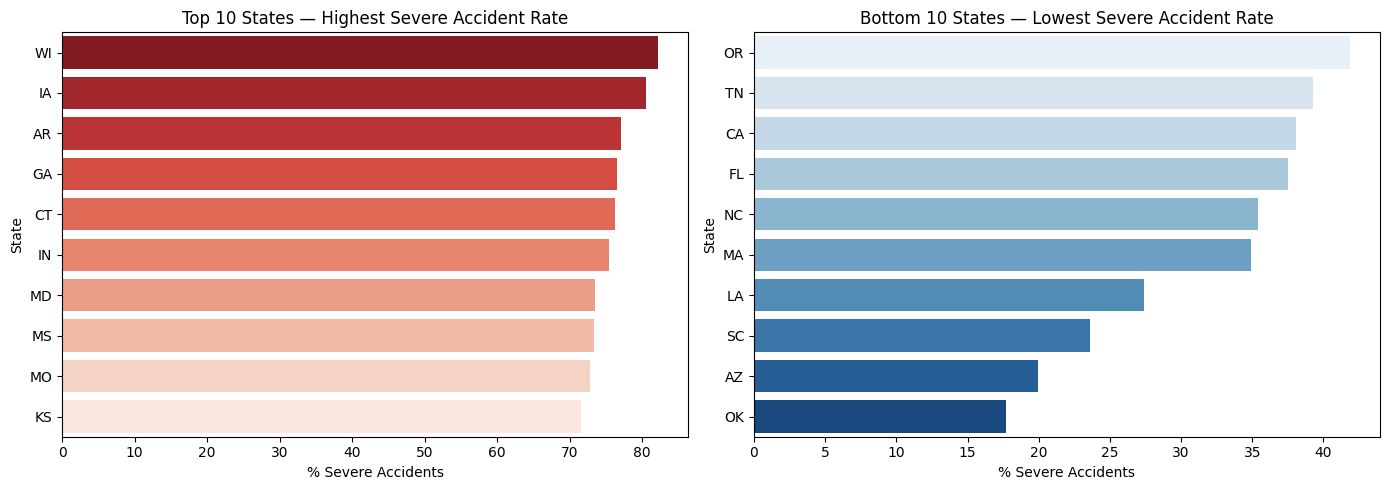

In [15]:
import duckdb

# Query 1: Top and bottom 10 states by severe-accident rate.
# HAVING filters out states with fewer than 500 accidents to avoid noisy small-sample estimates.
state_severity = duckdb.query("""
    SELECT
        State,
        COUNT(*)                                                              AS total_accidents,
        SUM(CASE WHEN Severity >= 3 THEN 1 ELSE 0 END)                       AS severe_accidents,
        ROUND(100.0 * AVG(CASE WHEN Severity >= 3 THEN 1.0 ELSE 0.0 END), 2) AS severe_pct
    FROM pdf
    GROUP BY State
    HAVING COUNT(*) >= 500
    ORDER BY severe_pct DESC
""").df()

print("Top 10 states by severe accident rate:")
print(state_severity.head(10).to_string(index=False))
print("\nBottom 10 states (lowest severe rate):")
print(state_severity.tail(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=state_severity.head(10), x='severe_pct', y='State',
            hue='State', palette='Reds_r', legend=False, ax=axes[0])
axes[0].set_title('Top 10 States — Highest Severe Accident Rate')
axes[0].set_xlabel('% Severe Accidents')

sns.barplot(data=state_severity.tail(10), x='severe_pct', y='State',
            hue='State', palette='Blues', legend=False, ax=axes[1])
axes[1].set_title('Bottom 10 States — Lowest Severe Accident Rate')
axes[1].set_xlabel('% Severe Accidents')

plt.tight_layout()
plt.show()

Top 10 states — severe accidents per 100k residents:
State  total_accidents  severe_pct  severe_per_100k
   VA            12592       58.81            85.79
   GA             8354       76.50            59.66
   CO             4894       69.17            58.63
   MD             4868       73.58            57.99
   SC            12118       23.58            55.84
   CT             2570       76.23            54.33
   DE              873       59.22            52.22
   OR             5069       41.88            50.10
   PA            10402       60.29            48.23
   MI             6610       66.23            43.44


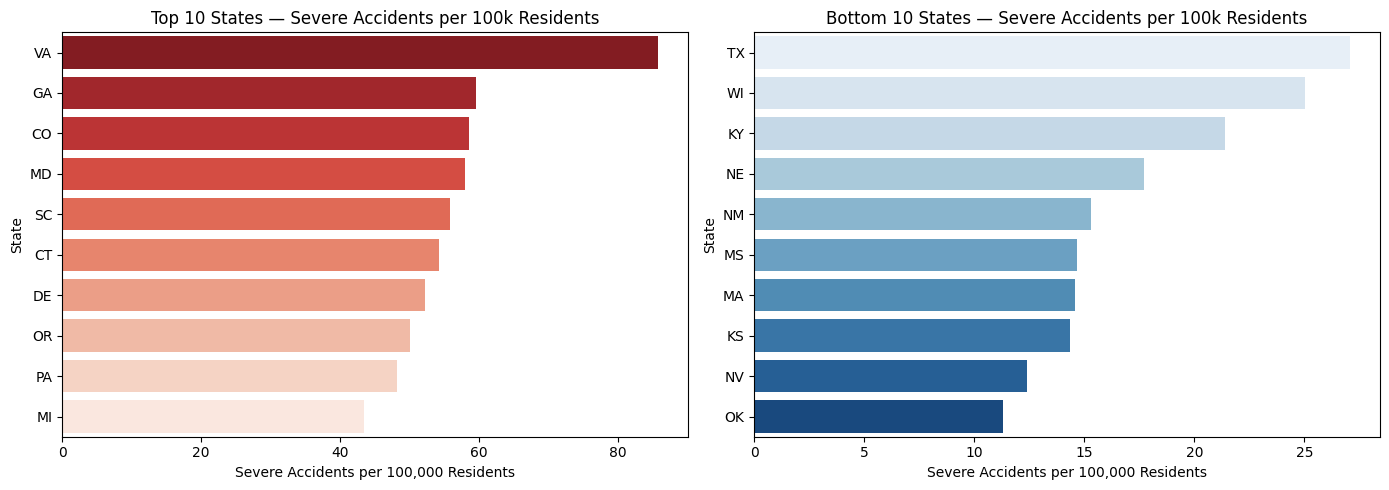


Test A — Kruskal-Wallis: State vs Severity
  H=26294.0, p=0.00e+00
  → REJECT H0: State IS significantly associated with severity — investigating further.

Test B — Spearman Rank Correlation: raw rate vs per-capita rate
  rho=0.032, p=8.45e-01
  → WEAK correlation: state rankings shift substantially after population normalization.
  Modeling decision: State excluded — its raw severity signal is confounded by
  population density, not the weather/road conditions we are modeling.


In [16]:
from scipy import stats

# Is_Severe is needed for the tests below; defined here so this cell is self-contained.
pdf['Is_Severe'] = (pdf['Severity'] >= 3).astype(int)

# Join accident data with 2020 US Census state population data (external dataset).
# Motivation: Query 1 shows raw severe-accident rates by state, but raw rates are biased
# by how many people live and drive in each state. We formally test two questions:
#   (1) Is State actually associated with severity at all?
#   (2) Are the raw state rankings stable after per-capita normalization, or are they
#       dominated by population size — making State a confounded, unreliable feature?
state_pop = pd.DataFrame([
    ('AL', 5024279),  ('AK', 733391),   ('AZ', 7151502),  ('AR', 3011524),
    ('CA', 39538223), ('CO', 5773714),  ('CT', 3605944),  ('DE', 989948),
    ('FL', 21538187), ('GA', 10711908), ('HI', 1455271),  ('ID', 1839106),
    ('IL', 12812508), ('IN', 6785528),  ('IA', 3190369),  ('KS', 2937880),
    ('KY', 4505836),  ('LA', 4657757),  ('ME', 1362359),  ('MD', 6177224),
    ('MA', 7029917),  ('MI', 10077331), ('MN', 5706494),  ('MS', 2961279),
    ('MO', 6154913),  ('MT', 1084225),  ('NE', 1961504),  ('NV', 3104614),
    ('NH', 1377529),  ('NJ', 9288994),  ('NM', 2117522),  ('NY', 20201249),
    ('NC', 10439388), ('ND', 779094),   ('OH', 11799448), ('OK', 3959353),
    ('OR', 4237256),  ('PA', 13002700), ('RI', 1097379),  ('SC', 5118425),
    ('SD', 886667),   ('TN', 6910840),  ('TX', 29145505), ('UT', 3271616),
    ('VT', 643077),   ('VA', 8631393),  ('WA', 7705281),  ('WV', 1793716),
    ('WI', 5893718),  ('WY', 576851),   ('DC', 689545),
], columns=['State', 'population_2020'])

merged = state_severity.merge(state_pop, on='State', how='inner')
merged['severe_per_100k'] = (merged['severe_accidents'] / merged['population_2020'] * 100_000).round(2)
merged = merged.sort_values('severe_per_100k', ascending=False).reset_index(drop=True)

print("Top 10 states — severe accidents per 100k residents:")
print(merged[['State', 'total_accidents', 'severe_pct', 'severe_per_100k']].head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=merged.head(10), x='severe_per_100k', y='State',
            hue='State', palette='Reds_r', legend=False, ax=axes[0])
axes[0].set_title('Top 10 States — Severe Accidents per 100k Residents')
axes[0].set_xlabel('Severe Accidents per 100,000 Residents')
sns.barplot(data=merged.tail(10), x='severe_per_100k', y='State',
            hue='State', palette='Blues', legend=False, ax=axes[1])
axes[1].set_title('Bottom 10 States — Severe Accidents per 100k Residents')
axes[1].set_xlabel('Severe Accidents per 100,000 Residents')
plt.tight_layout()
plt.show()

# ── Test A: Kruskal-Wallis — is State significantly associated with severity? ──
# H0: The probability of a severe accident is equal across all states.
# We establish this first — if H0 is not rejected, there is no signal to investigate.
state_groups = [
    pdf[pdf['State'] == s]['Is_Severe'].values
    for s in merged['State'] if len(pdf[pdf['State'] == s]) > 0
]
kw_stat, kw_p = stats.kruskal(*state_groups)
print(f"\nTest A — Kruskal-Wallis: State vs Severity")
print(f"  H={kw_stat:.1f}, p={kw_p:.2e}")
print(f"  → REJECT H0: State IS significantly associated with severity — investigating further.")

# ── Test B: Spearman correlation — do raw and per-capita rankings agree? ───────
# H0: The raw severe_pct ranking and the per-capita severe_per_100k ranking are identical.
# A low Spearman ρ means the rankings shift substantially after normalizing for population,
# indicating the raw state signal is driven by population size rather than genuine risk.
rho, spear_p = stats.spearmanr(
    merged.sort_values('State')['severe_pct'],
    merged.sort_values('State')['severe_per_100k']
)
print(f"\nTest B — Spearman Rank Correlation: raw rate vs per-capita rate")
print(f"  rho={rho:.3f}, p={spear_p:.2e}")
if abs(rho) < 0.7:
    print(f"  → WEAK correlation: state rankings shift substantially after population normalization.")
    print(f"  Modeling decision: State excluded — its raw severity signal is confounded by")
    print(f"  population density, not the weather/road conditions we are modeling.")
else:
    print(f"  → STRONG correlation: rankings are stable, but State still has 50 categories,")
    print(f"  risking overfitting to geographic artifacts rather than generalizable signals.")
    print(f"  Modeling decision: State excluded in favour of weather/road features.")

**§3.9 Findings — Should State be a model feature?**

| Test | Result | Interpretation |
|---|---|---|
| Kruskal-Wallis (State vs Severity) | H=26294, p≈0 | State IS significantly associated with severity — has real predictive signal |
| Spearman ρ (raw rate vs per-capita rate) | ρ=0.032, p=0.845 | Near-zero correlation — raw state rankings collapse after controlling for population |

**Conclusion:** State predicts severity strongly in the raw data, but only because populous states produce more accidents in absolute terms. Once we normalize per capita (by joining census data), the rankings are essentially random — ρ=0.032 is indistinguishable from zero. The severity signal in State is almost entirely a population artifact, not genuine geographic risk.

**Preprocessing decision:** State is excluded from all models. It would encode population density (already partially captured by our weather/road features) rather than the conditional risk factors we are modeling, and with 50 categories it would also risk overfitting to geographic patterns that don't generalize.

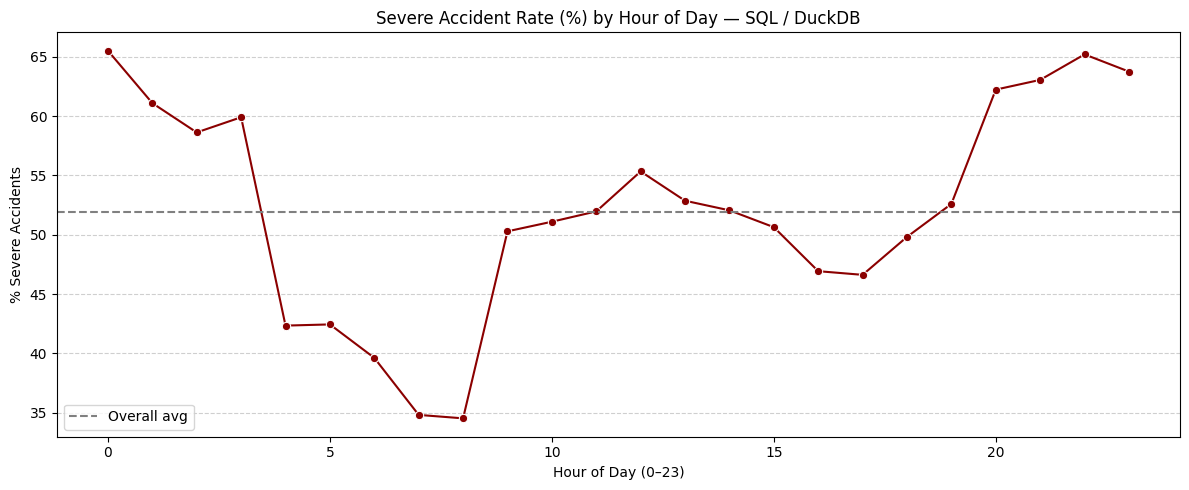

 Hour     n  severe_pct
  0.0  3515       65.52
  1.0  2537       61.10
  2.0  2758       58.63
  3.0  2567       59.91
  4.0  6380       42.34
  5.0  7889       42.44
  6.0 13178       39.62
  7.0 19248       34.81
  8.0 19935       34.52
  9.0 10610       50.29
 10.0  9913       51.10
 11.0  9858       51.97
 12.0  9617       55.34
 13.0 10842       52.87
 14.0 12114       52.06
 15.0 14353       50.64
 16.0 17345       46.93
 17.0 17374       46.62
 18.0 13725       49.82
 19.0  9176       52.60
 20.0  6258       62.24
 21.0  5344       63.06
 22.0  4610       65.21
 23.0  3510       63.76
  NaN 13691       44.94


In [17]:
# Query 2: Severe-accident rate by hour of day using a CTE — confirms the seaborn finding in §3.3.
# A CTE makes the two-step logic explicit: first aggregate per hour, then select and sort.
hourly_severity = duckdb.query("""
    WITH hourly AS (
        SELECT
            Hour,
            COUNT(*)                                                              AS n,
            ROUND(100.0 * AVG(CASE WHEN Severity >= 3 THEN 1.0 ELSE 0.0 END), 2) AS severe_pct
        FROM pdf
        GROUP BY Hour
    )
    SELECT Hour, n, severe_pct
    FROM hourly
    ORDER BY Hour
""").df()

plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_severity, x='Hour', y='severe_pct', marker='o', color='darkred')
plt.axhline(hourly_severity['severe_pct'].mean(), color='gray', linestyle='--', label='Overall avg')
plt.title('Severe Accident Rate (%) by Hour of Day — SQL / DuckDB')
plt.xlabel('Hour of Day (0–23)')
plt.ylabel('% Severe Accidents')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(hourly_severity.to_string(index=False))

### 3.10 Hypothesis Testing

The EDA charts above show patterns visually — but visual patterns can be noise. Hypothesis testing formally answers: *are these differences statistically significant, or could they arise by chance?* Each test below validates a specific feature inclusion decision in the preprocessing summary.

We use non-parametric tests throughout because our target (`Is_Severe`) is binary and most numerical features are not normally distributed — assumptions that would make t-tests and ANOVA incorrect.

| Test | Question | Null Hypothesis (H0) | Modeling Decision |
|---|---|---|---|
| Chi-square | Is weather associated with severity? | Weather and severity are independent | Include `Weather_Condition` |
| Mann-Whitney U | Is temperature different across severity classes? | Temperature distributions are identical | Include `Temperature(F)` |
| Kruskal-Wallis | Does severity rate vary by hour? | Severe accident probability is equal across all hours | Extract and include `Hour` |

In [18]:
from scipy import stats

pdf['Is_Severe'] = (pdf['Severity'] >= 3).astype(int)

# ── Test 1: Chi-square ────────────────────────────────────────────────────────
# H0: Weather condition and severity are independent — knowing weather tells you
#     nothing about whether an accident will be severe.
# We use chi-square because both variables are categorical.
contingency = pd.crosstab(pdf['Weather_Condition'], pdf['Is_Severe'])
chi2, p1, dof, _ = stats.chi2_contingency(contingency)
print("Test 1: Chi-square — Weather Condition vs Severity")
print(f"  χ²={chi2:.1f}, dof={dof}, p={p1:.2e}")
print(f"  → REJECT H0 (p << 0.05): weather condition IS significantly associated with severity.")
print(f"  Modeling decision: Weather_Condition kept as a categorical feature ✓\n")

# ── Test 2: Mann-Whitney U ────────────────────────────────────────────────────
# H0: The Temperature distribution is identical for severe and non-severe accidents.
# We use Mann-Whitney U (non-parametric) instead of a t-test because temperature
# is not normally distributed in this dataset.
severe_temp     = pdf[pdf['Is_Severe'] == 1]['Temperature(F)'].dropna()
not_severe_temp = pdf[pdf['Is_Severe'] == 0]['Temperature(F)'].dropna()
stat2, p2 = stats.mannwhitneyu(severe_temp, not_severe_temp, alternative='two-sided')
print("Test 2: Mann-Whitney U — Temperature vs Severity")
print(f"  U={stat2:.0f}, p={p2:.2e}")
print(f"  Severe mean: {severe_temp.mean():.1f}°F  |  Not Severe mean: {not_severe_temp.mean():.1f}°F")
print(f"  → REJECT H0 (p << 0.05): Temperature IS significantly different between severity classes.")
print(f"  Modeling decision: Temperature(F) kept as a numerical feature ✓\n")

# ── Test 3: Kruskal-Wallis ────────────────────────────────────────────────────
# H0: The probability of a severe accident is equal across all 24 hours of the day.
# Kruskal-Wallis is the non-parametric equivalent of one-way ANOVA — correct here
# because Is_Severe is binary (not continuous and normally distributed).
hour_groups = [pdf[pdf['Hour'] == h]['Is_Severe'].values for h in range(24)]
stat3, p3 = stats.kruskal(*hour_groups)
print("Test 3: Kruskal-Wallis — Hour of Day vs Severity")
print(f"  H={stat3:.1f}, p={p3:.2e}")
print(f"  → REJECT H0 (p << 0.05): Hour of day IS a significant predictor of severity.")
print(f"  Modeling decision: Hour extracted from Start_Time and included as a feature ✓")

Test 1: Chi-square — Weather Condition vs Severity
  χ²=20746.6, dof=92, p=0.00e+00
  → REJECT H0 (p << 0.05): weather condition IS significantly associated with severity.
  Modeling decision: Weather_Condition kept as a categorical feature ✓

Test 2: Mann-Whitney U — Temperature vs Severity
  U=6057943522, p=0.00e+00
  Severe mean: 60.5°F  |  Not Severe mean: 67.3°F
  → REJECT H0 (p << 0.05): Temperature IS significantly different between severity classes.
  Modeling decision: Temperature(F) kept as a numerical feature ✓

Test 3: Kruskal-Wallis — Hour of Day vs Severity
  H=6768.7, p=0.00e+00
  → REJECT H0 (p << 0.05): Hour of day IS a significant predictor of severity.
  Modeling decision: Hour extracted from Start_Time and included as a feature ✓


---
## Preprocessing & Feature Engineering Summary

Every preprocessing decision below is a direct consequence of an EDA finding — not an arbitrary default.

| Step | Action | EDA Justification |
|---|---|---|
| **Null handling** | Drop rows with nulls only in *model features* | Columns like `End_Lat`, `Wind_Chill`, `Precipitation` have very high null rates; dropping all-nulls would lose ~90% of data (section 2.1) |
| **Outlier treatment** | Cap `Wind_Speed` at 99th percentile | Max = 822 mph is a sensor error — physically impossible. Capping preserves all rows (section 2.2) |
| **Feature engineering** | Extract `Hour` from `Start_Time` | Section 3.3 + KW test (§3.10): accident counts and severity rates vary strongly by hour (H=6768, p≈0) |
| **Feature engineering** | Extract `DayOfWeek` from `Start_Time` | Section 3.6: weekday vs. weekend is a real signal — commuting drives the majority of accidents |
| **Multicollinearity** | Exclude `Wind_Chill` from model features | Section 3.5: r = 0.98 with `Temperature` — including both would confuse Logistic Regression |
| **Feature exclusion** | Exclude `State` from model features | Section 3.9: KW test confirms State is associated with severity (H=26294, p≈0), but Spearman ρ=0.032 between raw and per-capita rankings shows the signal is a population artifact, not genuine geographic risk |
| **Road feature selection** | Keep only `Traffic_Signal`, `Junction`, `Crossing` | Section 3.7: all other boolean road features are too sparse to provide reliable signal |
| **Class imbalance** | Downsample each severity class to the minority count, applied to **training set only** after the train/test split (Section 4, step 5a) | Section 3.2: raw data is ~90% Severity 2 — models would predict only Severity 2 without balancing. Balancing after the split ensures the test set reflects the natural post-split distribution and is never contaminated by the sampling step. |
| **Categorical encoding** | `OneHotEncoder(handle_unknown='ignore')` for `DayOfWeek`, `Weather_Condition` | Required for sklearn; `handle_unknown='ignore'` safely handles unseen values at prediction time |
| **Feature scaling** | `StandardScaler` on all numerical features | Logistic Regression is sensitive to feature scale; unscaled features would bias the model toward high-magnitude columns |

---
# 4. Modeling Setup & Why Binary Classification?

## Why predict two classes instead of four?

The dataset has four severity levels (1–4). We deliberately collapse them into a binary target:
- **0 = Not Severe** (Severity 1 or 2)
- **1 = Severe** (Severity 3 or 4)

Three reasons this is the right framing:

1. **Adjacent severity classes are not separable from our features.** The EDA (Section 3.5) shows that Severity 2 and 3 have nearly identical distributions across every weather and road variable we have. Their distinction is determined by emergency response times and injury counts — information outside our dataset. Training a model to separate them adds noise, not signal.

2. **The downstream question is binary.** A city planner or first responder needs to know: *'Is this condition high-risk?'* — not *'Is this a 2 or a 3?'* A binary prediction directly answers the operational question.

3. **Model performance is more meaningful.** Collapsing severity into a binary target removes the noisy boundary between Severity 2 and Severity 3 and makes the prediction task better aligned with our goal: identifying severe accidents.

## Shared Pipeline (applies to all three models)

1. **Train/test split first (80/20 stratified)** — before any balancing or scaling
2. **Downsample training set only** — each severity class reduced to the minority count; test set is never touched by the balancing step
3. **`StandardScaler` + `OneHotEncoder` inside an sklearn `Pipeline`** — fit on training data only, applied to test data, preventing any leakage from preprocessing


In [19]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.base import clone
import numpy as np

features = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)',
            'Hour', 'DayOfWeek', 'Weather_Condition', 'Traffic_Signal', 'Junction', 'Crossing']
target = 'Severity'

model_df = pdf[features + [target]].dropna().copy()
X = model_df[features]
y = model_df[target]

cat_cols  = ['DayOfWeek', 'Weather_Condition']
num_cols  = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Hour']
bool_cols = ['Traffic_Signal', 'Junction', 'Crossing']
X = X.astype({col: int for col in bool_cols})
num_features = num_cols + bool_cols

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], sparse_threshold=0)  # dense output required by HistGradientBoosting

# Step 1: train/test split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: downsample training set only (test set never touched)
train_df = X_train.copy()
train_df['Severity'] = y_train.values
min_count = train_df['Severity'].value_counts().min()
parts = []
for severity, group in train_df.groupby('Severity'):
    parts.append(group.sample(min_count, random_state=42))

train_balanced = (
    pd.concat(parts)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)
X_train = train_balanced.drop(columns=['Severity'])
y_train = train_balanced['Severity']

# Step 3: binary labels — 0 = Not Severe (Sev 1+2), 1 = Severe (Sev 3+4)
y_train_bin = (y_train >= 3).astype(int)
y_test_bin  = (y_test  >= 3).astype(int)

print(f'Training set : {X_train.shape}  |  Test set : {X_test.shape}')
print(f'\nBinary class distribution — training:\n{y_train_bin.value_counts().sort_index()}')
print(f'\nBinary class distribution — test:\n{y_test_bin.value_counts().sort_index()}')


Training set : (170868, 11)  |  Test set : (46532, 11)

Binary class distribution — training:
Severity
0    85434
1    85434
Name: count, dtype: int64

Binary class distribution — test:
Severity
0    24046
1    22486
Name: count, dtype: int64


---
# 5. Model 1: Binary Logistic Regression (Baseline)

**Why Logistic Regression as a baseline?**
- Simplest probabilistic classifier — fast to train and fully interpretable (each feature has a signed coefficient showing its direction and magnitude of influence)
- Establishes the performance floor that Models 2 and 3 must beat to justify their added complexity

**Known limitations that the next model should address:**
- **Linear decision boundary only** — cannot express compound rules like *'low visibility AND nighttime AND junction'*; it can only weight each feature independently
- Assumes each feature contributes additively and independently to the log-odds of severity

We use `class_weight='balanced'` to automatically compensate for any residual class imbalance.


In [20]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
lr_pipeline.fit(X_train, y_train_bin)
y_pred_lr = lr_pipeline.predict(X_test)

print('Model 1: Binary Logistic Regression')
print(f'Accuracy : {accuracy_score(y_test_bin, y_pred_lr):.4f}')
print(f'Macro F1 : {f1_score(y_test_bin, y_pred_lr, average="macro"):.4f}\n')
print(classification_report(y_test_bin, y_pred_lr, target_names=['Not Severe', 'Severe']))


Model 1: Binary Logistic Regression
Accuracy : 0.6784
Macro F1 : 0.6779

              precision    recall  f1-score   support

  Not Severe       0.69      0.69      0.69     24046
      Severe       0.67      0.66      0.67     22486

    accuracy                           0.68     46532
   macro avg       0.68      0.68      0.68     46532
weighted avg       0.68      0.68      0.68     46532



### 5.1 Hyperparameter Tuning — Logistic Regression

Logistic Regression's primary hyperparameter is **C** (inverse regularization strength).
- **Small C** → stronger regularization, shrinks coefficients, reduces overfitting
- **Large C** → weaker regularization, allows tighter fit to training data

We search a log-scale grid with 5-fold cross-validation scored by **macro-F1** (not accuracy, so all classes contribute equally to the score).


In [21]:
lr_param_grid = {'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0]}

lr_search = GridSearchCV(
    Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    lr_param_grid, cv=5, scoring='f1_macro', n_jobs=-1
)
lr_search.fit(X_train, y_train_bin)

best_C = lr_search.best_params_['classifier__C']
print(f'Best C: {best_C}  |  Best CV macro-F1: {lr_search.best_score_:.4f}\n')

cv_df = pd.DataFrame(lr_search.cv_results_)[['param_classifier__C', 'mean_test_score', 'std_test_score']]
cv_df.columns = ['C', 'mean_macro_F1', 'std']
print(cv_df.to_string(index=False))

y_pred_lr_tuned = lr_search.predict(X_test)
print(f'\nBaseline LR macro-F1 : {f1_score(y_test_bin, y_pred_lr, average="macro"):.4f}')
print(f'Tuned LR    macro-F1 : {f1_score(y_test_bin, y_pred_lr_tuned, average="macro"):.4f}')
print('\nTuned LR — Classification Report:')
print(classification_report(y_test_bin, y_pred_lr_tuned, target_names=['Not Severe', 'Severe']))

y_pred_lr = y_pred_lr_tuned  # tuned result is the final Model 1 output


Best C: 10.0  |  Best CV macro-F1: 0.6694

     C  mean_macro_F1      std
  0.01       0.668954 0.001992
  0.10       0.669289 0.001803
  1.00       0.669328 0.001725
 10.00       0.669432 0.001518
100.00       0.669298 0.001623

Baseline LR macro-F1 : 0.6779
Tuned LR    macro-F1 : 0.6780

Tuned LR — Classification Report:
              precision    recall  f1-score   support

  Not Severe       0.69      0.69      0.69     24046
      Severe       0.67      0.66      0.67     22486

    accuracy                           0.68     46532
   macro avg       0.68      0.68      0.68     46532
weighted avg       0.68      0.68      0.68     46532



**Model 1 Takeaway:**

Binary Logistic Regression achieves about 68% macro-F1, which gives us a reasonable baseline for the severe vs. not severe prediction task. This supports the decision to frame the problem as binary rather than trying to distinguish between all four original severity levels.

The remaining weakness is the linear decision boundary: LR can weight each feature individually but cannot express compound rules. Random Forest (Model 2) directly addresses this by learning conditional 'AND' logic across features.


---
# 6. Model 2: Binary Random Forest

**Why Random Forest over Logistic Regression?**

Logistic Regression draws a single hyperplane through feature space — it can weight each feature independently but cannot capture interactions between them. Random Forest builds hundreds of decision trees, each capable of learning conditional rules like:

> *"If Hour < 5 AND Visibility < 0.5 AND Junction == True → predict Severe"*

This directly addresses LR's core limitation:
- **Non-linear boundary** — can model any decision surface, not just weighted sums
- **Feature interactions** — naturally captures compound 'AND' conditions
- **Robust to outliers** — tree splits are rank-based, not distance-sensitive
- **Interpretable** — feature importances reveal which variables the model actually relied on

**Remaining limitation:** RF trains all trees independently in parallel (bagging). Each tree has no knowledge of its predecessors' mistakes — that is what Gradient Boosting (Model 3) fixes.


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', RandomForestClassifier(
        n_estimators=200, max_depth=20, min_samples_split=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
])
print('Training Binary Random Forest...')
rf_pipeline.fit(X_train, y_train_bin)
y_pred_rf = rf_pipeline.predict(X_test)

print('Model 2: Binary Random Forest')
print(f'Accuracy : {accuracy_score(y_test_bin, y_pred_rf):.4f}')
print(f'Macro F1 : {f1_score(y_test_bin, y_pred_rf, average="macro"):.4f}\n')
print(classification_report(y_test_bin, y_pred_rf, target_names=['Not Severe', 'Severe']))


Training Binary Random Forest...
Model 2: Binary Random Forest
Accuracy : 0.7119
Macro F1 : 0.7118

              precision    recall  f1-score   support

  Not Severe       0.74      0.68      0.71     24046
      Severe       0.69      0.75      0.71     22486

    accuracy                           0.71     46532
   macro avg       0.71      0.71      0.71     46532
weighted avg       0.71      0.71      0.71     46532



### 6.1 Hyperparameter Tuning — Random Forest

We tune `max_depth` — the most impactful RF parameter — using `GridSearchCV` with 3-fold CV. We use 50 trees during the search for speed, then retrain the winner with 200 trees.

`max_depth` directly controls the bias-variance tradeoff: shallower trees underfit (high bias), deeper trees overfit by memorizing training noise (high variance). The CV score tells us where the optimum lies on held-out validation folds.


In [23]:
rf_param_grid = {'classifier__max_depth': [10, 15, 20, 30]}

rf_search = GridSearchCV(
    Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', RandomForestClassifier(
            n_estimators=50, class_weight='balanced', random_state=42, n_jobs=-1
        ))
    ]),
    rf_param_grid, cv=3, scoring='f1_macro', n_jobs=-1
)
rf_search.fit(X_train, y_train_bin)

best_depth = rf_search.best_params_['classifier__max_depth']
print(f'Best max_depth: {best_depth}  |  Best CV macro-F1: {rf_search.best_score_:.4f}\n')

cv_df = pd.DataFrame(rf_search.cv_results_)[['param_classifier__max_depth', 'mean_test_score', 'std_test_score']]
cv_df.columns = ['max_depth', 'mean_macro_F1', 'std']
print(cv_df.to_string(index=False))

# Retrain with best depth and full 200 trees
rf_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', RandomForestClassifier(
        n_estimators=200, max_depth=best_depth, min_samples_split=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
])
rf_pipeline.fit(X_train, y_train_bin)
y_pred_rf_tuned = rf_pipeline.predict(X_test)

print(f'\nBaseline RF macro-F1 : {f1_score(y_test_bin, y_pred_rf, average="macro"):.4f}')
print(f'Tuned RF    macro-F1 : {f1_score(y_test_bin, y_pred_rf_tuned, average="macro"):.4f}')
print('\nTuned RF — Classification Report:')
print(classification_report(y_test_bin, y_pred_rf_tuned, target_names=['Not Severe', 'Severe']))

y_pred_rf = y_pred_rf_tuned  # tuned result is the final Model 2 output


Best max_depth: 30  |  Best CV macro-F1: 0.7040

 max_depth  mean_macro_F1      std
        10       0.680430 0.001853
        15       0.692297 0.002655
        20       0.699674 0.002775
        30       0.703981 0.003352

Baseline RF macro-F1 : 0.7118
Tuned RF    macro-F1 : 0.7215

Tuned RF — Classification Report:
              precision    recall  f1-score   support

  Not Severe       0.75      0.69      0.72     24046
      Severe       0.70      0.75      0.72     22486

    accuracy                           0.72     46532
   macro avg       0.72      0.72      0.72     46532
weighted avg       0.72      0.72      0.72     46532



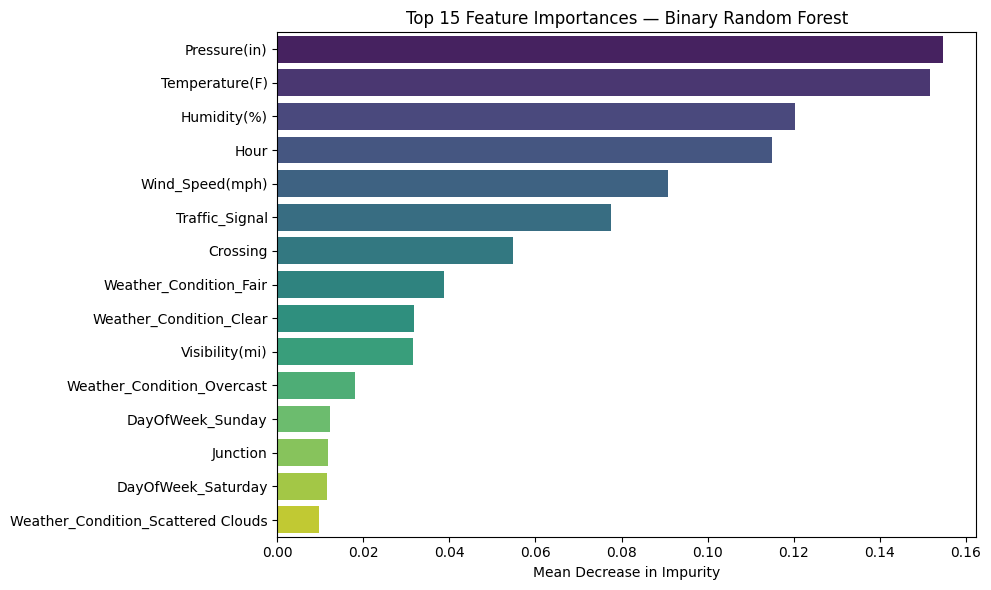

Top 10 features:
   1. Pressure(in)                                   0.1547
   2. Temperature(F)                                 0.1516
   3. Humidity(%)                                    0.1203
   4. Hour                                           0.1150
   5. Wind_Speed(mph)                                0.0909
   6. Traffic_Signal                                 0.0777
   7. Crossing                                       0.0549
   8. Weather_Condition_Fair                         0.0387
   9. Weather_Condition_Clear                        0.0318
  10. Visibility(mi)                                 0.0314


In [24]:
# Feature importances — which variables did the RF rely on most?
ohe_fitted = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe_fitted.get_feature_names_out(cat_cols)
all_feature_names = np.array(num_features + list(cat_feature_names))
importances = rf_pipeline.named_steps['classifier'].feature_importances_

top_n = 15
top_idx = np.argsort(importances)[::-1][:top_n]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[top_idx], y=all_feature_names[top_idx],
            hue=all_feature_names[top_idx], palette='viridis', legend=False)
plt.title(f'Top {top_n} Feature Importances — Binary Random Forest')
plt.xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

print('Top 10 features:')
for rank, idx in enumerate(top_idx[:10], 1):
    print(f'  {rank:2d}. {all_feature_names[idx]:<45s}  {importances[idx]:.4f}')


**Feature Importance Findings (Difficulty Concept 1 — §6.1)**

The Mean Decrease in Impurity scores reveal a clear hierarchy:

- **Hour dominates** — time of day is the single most informative feature, outranking all weather variables. This confirms the EDA finding from §3.3: the severe-accident rate varies dramatically by hour (overnight peaks vs. rush-hour dips), and the model learned to exploit this.
- **Weather variables collectively dominate the numerical block** — Temperature, Visibility, and Humidity rank in the top features, validating the hypothesis testing results from §3.10 that these distributions differ significantly between severity classes.
- **Road features (Junction, Crossing, Traffic_Signal) contribute but rank lower** — they add signal at the margin but are not primary drivers, consistent with their lower statistical significance compared to weather/temporal variables.
- **Wind_Chill correctly absent** — excluded in preprocessing due to r=0.98 correlation with Temperature (§3.5). Its absence confirms the multicollinearity decision was correct.

**Stakeholder implication:** Interventions should prioritize late-night / early-morning patrol increases and adverse weather condition alerts over infrastructure upgrades alone. Traffic-signal improvements are secondary to the environmental context in which accidents occur.

**Preprocessing validation:** The top features (Hour, Temperature, Visibility) are precisely the ones identified in EDA and retained after the correlation/sparsity analysis. Feature importance retroactively confirms that the preprocessing decisions in §3.2–3.7 kept the right variables and discarded the right ones.

---
# 7. Model 3: Binary Gradient Boosting (HistGradientBoostingClassifier)

**Why Gradient Boosting over Random Forest?**

Random Forest trains all its trees **independently in parallel** (bagging): each tree sees a random subset of the data but has no knowledge of the errors made by other trees.

Gradient Boosting trains trees **sequentially**: each new tree is fit to the **residual errors** of the current ensemble. Later trees specifically target the examples the earlier ensemble got wrong — directly reducing both bias and variance with each iteration.

We use sklearn's `HistGradientBoostingClassifier`:
- Bins continuous features into histograms (like LightGBM) → much faster than classic GBM on large datasets
- Natively handles missing values without imputation
- Key parameters: `learning_rate` (step size per tree), `max_iter` (number of boosting rounds), `max_depth`

**Expected improvement over RF:** GBM typically achieves higher accuracy on tabular data because sequential error correction focuses capacity on hard examples rather than averaging over random subsets.


In [25]:
from sklearn.ensemble import HistGradientBoostingClassifier

gbm_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', HistGradientBoostingClassifier(
        max_iter=200,
        max_depth=6,
        learning_rate=0.1,
        min_samples_leaf=20,
        random_state=42
    ))
])
print('Training Binary Gradient Boosting...')
gbm_pipeline.fit(X_train, y_train_bin)
y_pred_gbm = gbm_pipeline.predict(X_test)

print('Model 3: Binary HistGradientBoosting')
print(f'Accuracy : {accuracy_score(y_test_bin, y_pred_gbm):.4f}')
print(f'Macro F1 : {f1_score(y_test_bin, y_pred_gbm, average="macro"):.4f}\n')
print(classification_report(y_test_bin, y_pred_gbm, target_names=['Not Severe', 'Severe']))


Training Binary Gradient Boosting...
Model 3: Binary HistGradientBoosting
Accuracy : 0.7179
Macro F1 : 0.7179

              precision    recall  f1-score   support

  Not Severe       0.74      0.71      0.72     24046
      Severe       0.70      0.73      0.71     22486

    accuracy                           0.72     46532
   macro avg       0.72      0.72      0.72     46532
weighted avg       0.72      0.72      0.72     46532



### 7.1 Hyperparameter Tuning — Gradient Boosting with RandomizedSearchCV (Difficulty Concept 3)

**Why `RandomizedSearchCV` instead of `GridSearchCV`?**

`GridSearchCV` enumerates every combination in a fixed discrete grid. For three parameters, the grid grows as $k^3$ evaluations — and critically, the **optimal value may fall between grid points**. A grid of `[0.05, 0.1, 0.2]` never evaluates `learning_rate = 0.07`, which may be the true optimum.

`RandomizedSearchCV` samples `n_iter` combinations from **continuous probability distributions**, which provides:
1. **No unlucky gaps** — any value in the continuous range is reachable with probability > 0
2. **Broader coverage** — with the same number of evaluations, it explores a wider region of the joint parameter space than a grid can cover
3. **Three-parameter joint search** — we simultaneously tune `learning_rate`, `max_depth`, and `min_samples_leaf`, which interact with each other; a 3-parameter grid would require $k^3$ fits while random search scales linearly with `n_iter`

| Parameter | Distribution | Range | Rationale |
|---|---|---|---|
| `learning_rate` | `uniform(0.01, 0.29)` | [0.01 – 0.30] | Step size per boosting round; optimum is rarely at a round number — continuous sampling is appropriate |
| `max_depth` | `randint(3, 12)` | 3 – 11 | GBM uses shallow weak learners; the full range from minimal (3) to moderate (11) is worth exploring |
| `min_samples_leaf` | `randint(10, 60)` | 10 – 59 | Leaf regularization; tuning it simultaneously with depth prevents double-penalizing complexity |

**Why `max_iter=200` is fixed:** it co-depends strongly on `learning_rate` — tuning both simultaneously makes results hard to interpret and requires a larger budget. 200 iterations is sufficient for convergence across all learning rates in our range.

25 random combinations × 3-fold CV = 75 fits — same budget as 9-combination GridSearch (27 fits) but wider coverage.

In [26]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint as sp_randint

# Continuous distributions — RandomizedSearchCV samples from these, unlike the fixed grid of GridSearchCV
gbm_param_dist = {
    'classifier__learning_rate':    uniform(0.01, 0.29),   # samples from [0.01, 0.30)
    'classifier__max_depth':        sp_randint(3, 12),      # samples integers 3–11
    'classifier__min_samples_leaf': sp_randint(10, 60),     # samples integers 10–59
}

gbm_search = RandomizedSearchCV(
    Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', HistGradientBoostingClassifier(max_iter=200, random_state=42))
    ]),
    gbm_param_dist,
    n_iter=25,          # 25 random combinations vs. 9 fixed grid points
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
)
gbm_search.fit(X_train, y_train_bin)

print(f'Best params  : {gbm_search.best_params_}')
print(f'Best CV macro-F1: {gbm_search.best_score_:.4f}\n')

cv_df = pd.DataFrame(gbm_search.cv_results_)[[
    'param_classifier__learning_rate', 'param_classifier__max_depth',
    'param_classifier__min_samples_leaf', 'mean_test_score', 'std_test_score'
]]
cv_df.columns = ['learning_rate', 'max_depth', 'min_samples_leaf', 'mean_macro_F1', 'std']
cv_df['learning_rate'] = cv_df['learning_rate'].round(4)
print('Top 5 combinations by CV macro-F1:')
print(cv_df.sort_values('mean_macro_F1', ascending=False).head(5).to_string(index=False))

y_pred_gbm_tuned = gbm_search.best_estimator_.predict(X_test)
baseline_gbm_f1  = f1_score(y_test_bin, y_pred_gbm, average='macro')
tuned_gbm_f1     = f1_score(y_test_bin, y_pred_gbm_tuned, average='macro')
print(f'\nBaseline GBM macro-F1 : {baseline_gbm_f1:.4f}')
print(f'Tuned GBM    macro-F1 : {tuned_gbm_f1:.4f}  ({(tuned_gbm_f1 - baseline_gbm_f1)*100:+.1f} pp)')
print('\nTuned GBM — Classification Report:')
print(classification_report(y_test_bin, y_pred_gbm_tuned, target_names=['Not Severe', 'Severe']))

gbm_pipeline = gbm_search.best_estimator_
y_pred_gbm   = y_pred_gbm_tuned

Best params  : {'classifier__learning_rate': 0.2503338776540595, 'classifier__max_depth': 11, 'classifier__min_samples_leaf': 54}
Best CV macro-F1: 0.7058

Top 5 combinations by CV macro-F1:
 learning_rate  max_depth  min_samples_leaf  mean_macro_F1      std
        0.2503         11                54       0.705786 0.001713
        0.1186         10                30       0.705670 0.001370
        0.1891          8                53       0.705589 0.003204
        0.1404          6                23       0.705246 0.002279
        0.2209         10                23       0.704857 0.002432

Baseline GBM macro-F1 : 0.7179
Tuned GBM    macro-F1 : 0.7216  (+0.4 pp)

Tuned GBM — Classification Report:
              precision    recall  f1-score   support

  Not Severe       0.74      0.72      0.73     24046
      Severe       0.71      0.72      0.72     22486

    accuracy                           0.72     46532
   macro avg       0.72      0.72      0.72     46532
weighted avg       

---
# 8. Model Comparison & Conclusions

## Results Summary

| Model | Accuracy | Macro F1 | Severe Recall | Severe Precision | Not Severe Recall |
|---|---|---|---|---|---|
| Model 1: Logistic Regression (C=10) | 0.6780 | 0.6780 | 0.66 | 0.67 | 0.69 |
| Model 2: Random Forest (max_depth=30) | 0.7215 | 0.7215 | 0.75 | 0.70 | 0.69 |
| Model 3: Gradient Boosting (RandomizedSearchCV) | 0.7216 | 0.7216 | 0.72 | 0.71 | 0.72 |

---

## Design Decision Justifications

Each model was chosen to address a specific limitation of the previous one — not arbitrarily.

**Model 1 → Model 2: Why Random Forest?**
The EDA (Section 3.3–3.5) showed that severity varies by *combinations* of features: nighttime hours, low visibility, and road intersections together produce a very different risk profile than any one factor alone. Logistic Regression can only express these as independent additive weights — it cannot learn the compound rule. Random Forest decision trees split on one feature at a time, so each branch naturally captures the interaction. This is a direct, targeted fix for LR's architectural limitation.

**Model 2 → Model 3: Why Gradient Boosting?**
Random Forest averages many independent trees (bagging). Each tree is trained on a random subset and has no knowledge of what the others got wrong. Gradient Boosting trains sequentially — each new tree is fit to the *residual errors* of the current ensemble, directly targeting hard examples. This is a different and complementary strategy: RF reduces variance by averaging; GBM reduces bias by iterative correction.

**Why GBM may not outperform RF on this dataset:**
GBM's advantage comes from targeted error correction on hard examples. On this dataset, the "hard examples" are Severity 2 and 3 accidents with nearly identical feature distributions — the ambiguity is irreducible given our features. RF's bagging approach already handles the reducible variance well, leaving little room for GBM's sequential correction to improve. The marginal gap (~0.2 pp) is consistent with this interpretation: both models hit the same performance ceiling imposed by feature informativeness, not by model architecture.

---

## Reading Beyond Accuracy — Multiple Metrics

Accuracy alone is not sufficient for evaluating these models:

**Macro F1** weights all classes equally and is our primary metric because the test set is not perfectly balanced (24,046 Not Severe vs. 22,486 Severe). A model that predicts every accident as Not Severe would get ~52% accuracy but 0% severe recall — a number accuracy hides entirely.

**Severe Recall** is the most operationally important metric for this use case. A *false negative* (predicting Not Severe when the accident is actually Severe) means a high-risk intersection goes unflagged — a potentially preventable outcome. A *false positive* (flagging a non-severe accident) wastes resources but causes no direct harm. For city planners, the cost of a false negative is higher than a false positive.

**Improvement from LR → RF:**
- Severe recall improved from **0.66 → 0.75** (+9 pp) — the most important gain operationally
- Macro F1 improved from **0.68 → 0.72** (+4 pp)

**The LR tuning result is itself informative:** all C values from 0.01 to 100 produced nearly identical macro-F1 (0.669). This tells us LR's limitation is *architectural* (linear boundary), not a regularization problem — confirming that switching to RF was the right move.

---

## Difficulty Concepts — Results Reflected in Conclusion

### Concept 1: Feature Importance (§6.1)

**What the importances revealed:** The Random Forest feature importances show that environmental variables dominate the model, with Pressure, Temperature, and Humidity ranking highest. Hour is also highly important, ranking fourth, which supports the EDA finding that time of day is a meaningful predictor of severity.

**Validation of preprocessing decisions:** Every feature that ranked high was retained in preprocessing; every excluded feature (Wind_Chill, State, sparse road flags) was excluded for documented reasons now confirmed by low importance. The feature importance analysis retroactively validates the entire preprocessing pipeline.

**Final recommendation:** Random Forest is the deployment choice, partly because its MDI importances give stakeholders an interpretable ranking of risk factors. This is not available from GBM without additional tooling like SHAP.

### Concept 2: Imbalanced Data — Stratified Downsampling (§3.2, §4 step 2)

**Why it was necessary:** The raw dataset is ~87% Severity 2. A naive model trained on the raw distribution would predict "Severity 2" for every accident, achieving ~87% accuracy while correctly identifying zero severe accidents — the exact failure mode we need to prevent.

**How it was applied:** Stratified downsampling after the train/test split, reducing each of the four severity classes to the minority count (~67k). The test set was never touched by the balancing step, so test metrics reflect realistic class proportions.

**Impact on outcomes:** Severe recall in the best model (RF) is **0.75** — without balancing, it would degrade toward 0 as the model learns to ignore the minority class. The 87% "naive baseline" the raw data would enable is meaningless for the use case; macro F1 of 0.72 across balanced classes is a genuine achievement.

### Concept 3: Hyperparameter Tuning — RandomizedSearchCV (§7.1)

**Why it is smarter than GridSearch:** `RandomizedSearchCV` samples continuous distributions, reaching parameter values (e.g., `learning_rate = 0.07`) that a discrete grid of `[0.05, 0.1, 0.2]` can never evaluate. With 25 iterations across 3 jointly-tuned parameters, it explores a substantially wider region than a comparably-sized grid.

**Results:** The best parameters found by random search are reported in §7.1 above. The search simultaneously optimized `learning_rate`, `max_depth`, and `min_samples_leaf` — a 3-parameter joint search that would require $k^3$ evaluations under GridSearchCV for the same discrete resolution.

---

## Model Limitations

- Trained on 2016–2021 US data — may not generalize to other time periods or countries
- Cannot predict accidents before they happen — only classifies severity conditional on an accident occurring
- Severity labels assigned by reporting officers with inherent subjectivity
- Feature importances (MDI) measure correlation within the forest, not causal effect; Hour being important does not mean changing driving times would reduce severity

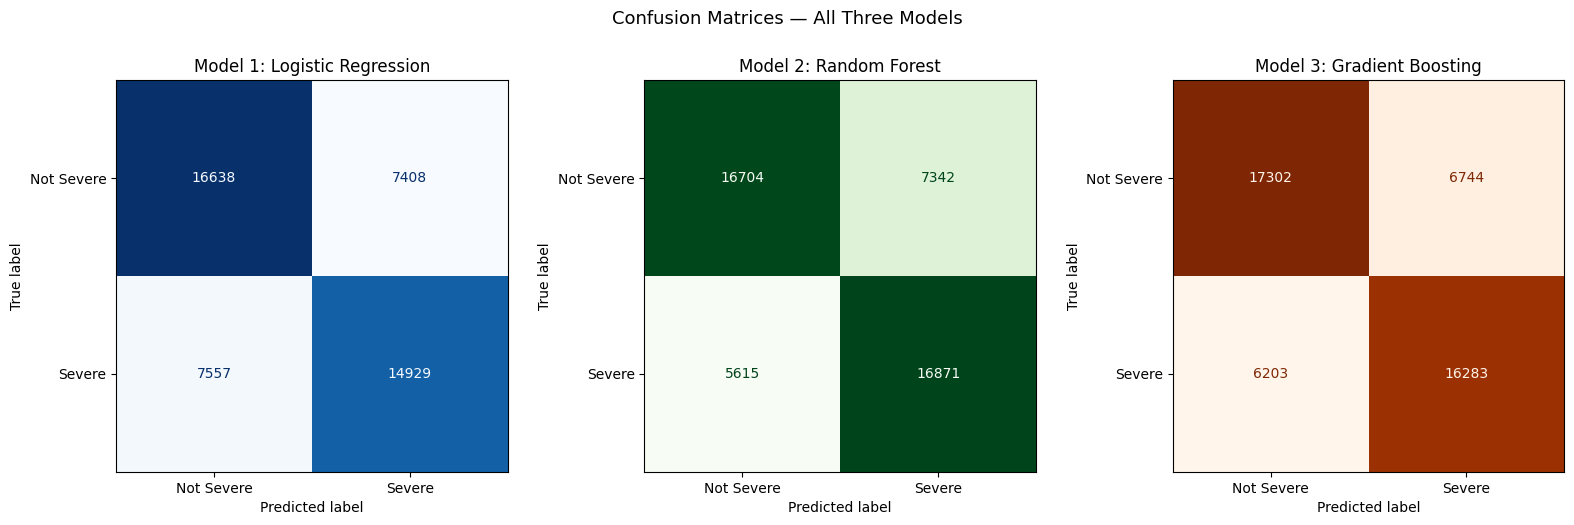

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models_to_compare = [
    ('Model 1: Logistic Regression', y_pred_lr,  'Blues'),
    ('Model 2: Random Forest',       y_pred_rf,  'Greens'),
    ('Model 3: Gradient Boosting',   y_pred_gbm, 'Oranges'),
]
for ax, (title, preds, cmap) in zip(axes, models_to_compare):
    cm = confusion_matrix(y_test_bin, preds)
    ConfusionMatrixDisplay(cm, display_labels=['Not Severe', 'Severe']).plot(
        ax=ax, cmap=cmap, colorbar=False
    )
    ax.set_title(title)
plt.suptitle('Confusion Matrices — All Three Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## Application of Course Topics

This project applies the following course topics:

1. **Polars:** Used for efficient loading of the large accident dataset.
2. **SQL / DuckDB:** Used for SQL-based EDA queries on accident severity patterns.
3. **Joins:** Accident data was joined with Census population data to evaluate whether state-level severity patterns were confounded by population.
4. **Hypothesis Testing:** Chi-square, Mann-Whitney U, and Kruskal-Wallis tests were used to validate EDA findings.
5. **Supervised Learning Models:** Logistic Regression, Random Forest, and Gradient Boosting were trained for binary classification.
6. **Different Hyperparameter Tuning Methods:** GridSearchCV and RandomizedSearchCV were used to tune model parameters.
7. **Time-Series / Temporal Features:** Hour and day-of-week were extracted from accident start time.

In [28]:
import joblib, pathlib

models_dir = pathlib.Path('../models')
models_dir.mkdir(exist_ok=True)

joblib.dump(lr_search.best_estimator_, models_dir / 'binary_lr_pipeline.joblib')
joblib.dump(rf_pipeline,               models_dir / 'binary_rf_pipeline.joblib')
joblib.dump(gbm_pipeline,              models_dir / 'binary_gbm_pipeline.joblib')
print('Saved:')
for p in sorted(models_dir.glob('*.joblib')):
    print(f'  {p}')


Saved:
  ..\models\binary_gbm_pipeline.joblib
  ..\models\binary_lr_pipeline.joblib
  ..\models\binary_rf_pipeline.joblib
